In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data_science_job.csv")

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.shape

(19158, 13)

In [5]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [8]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [9]:
# now we filter the columns in which the missing values are less than 5%

In [11]:
col = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]

In [12]:
col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [14]:
df[col].sample(4)

,city_development_index,enrolled_university,education_level,experience,training_hours
17975,0.920,no_enrollment,Graduate,10.0,21.0
13091,0.920,Full time course,Graduate,2.0,202.0
18448,0.920,no_enrollment,Primary School,5.0,44.0
7837,0.887,Full time course,High School,1.0,31.0


In [15]:
# find after dropping the missing values how many values will left in the column

In [16]:
len(df[col].dropna())/len(df)

0.8968577095730244

In [17]:
new_df = df[col].dropna()

In [18]:
df.shape, new_df.shape

((19158, 13), (17182, 5))

In [19]:
df.shape[0] - new_df.shape[0]

1976

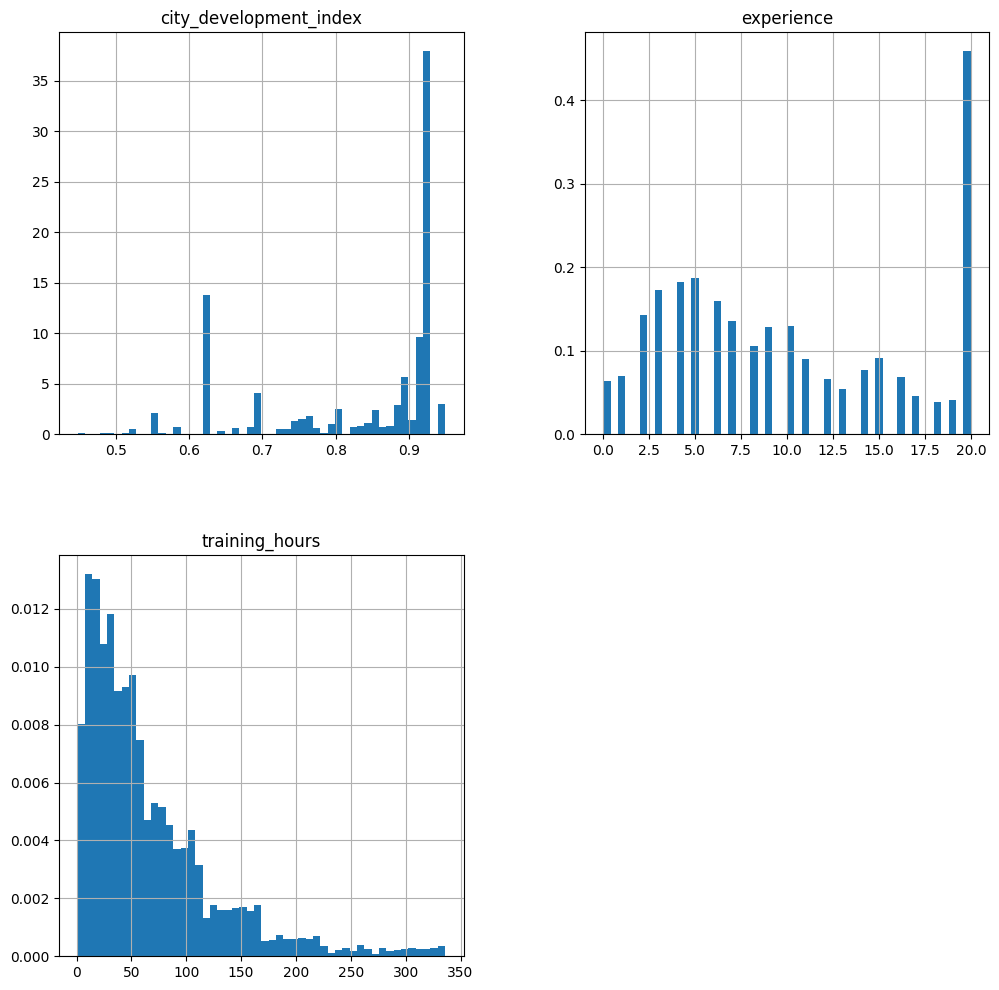

In [20]:
new_df.hist(bins=50, density=True, figsize=(12,12))
plt.show()

In [21]:
# Now we will plot the histogram(distribution) of the columns before dropping the null values and after dropping the null values.

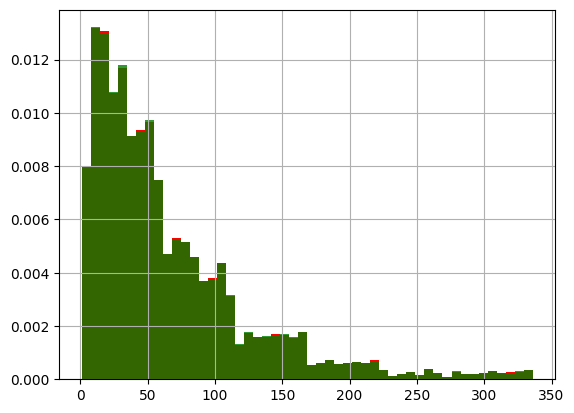

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

# before dropping the null values(original data)
df["training_hours"].hist(bins=50, ax=ax, density = True, color="red")

# after dropping the null values
new_df["training_hours"].hist(bins=50, ax=ax ,density=True, color="green", alpha=0.8)
# argument alpha makes the color transparent

plt.show()

In [28]:
# PDF plot

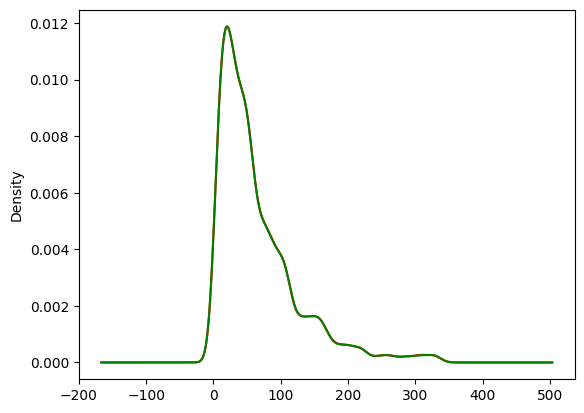

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# before dropping the null values(original data)
df["training_hours"].plot.density(color="red")

# after dropping the null values
new_df["training_hours"].plot.density(color="green")

plt.show()

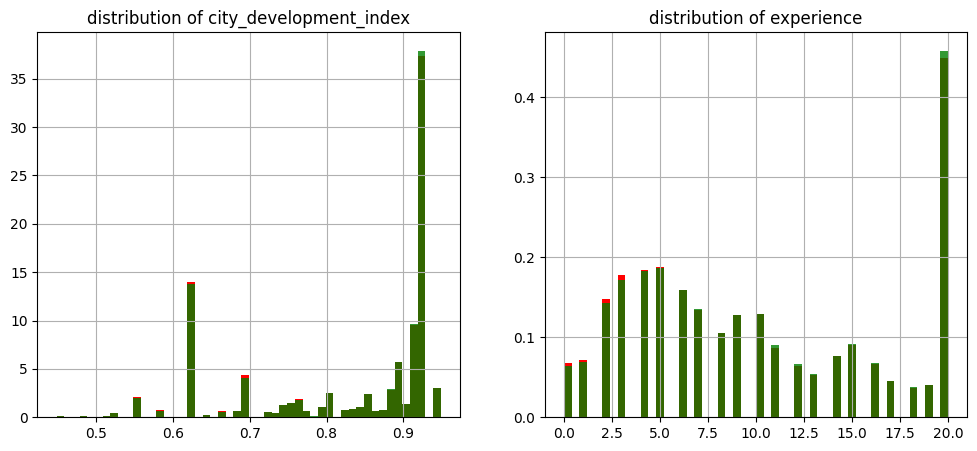

In [38]:
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)

# before dropping the null values(original data)
df["city_development_index"].hist(bins=50, ax=ax1, density = True, color="red")

# after dropping the null values
new_df["city_development_index"].hist(bins=50, ax=ax1 ,density=True, color="green", alpha=0.8)
# argument alpha makes the color transparent
plt.title("distribution of city_development_index")

ax2 = fig.add_subplot(122)
# before dropping the null values(original data)
df["experience"].hist(bins=50, ax=ax2, density = True, color="red")

# after dropping the null values
new_df["experience"].hist(bins=50, ax=ax2 ,density=True, color="green", alpha=0.8)
# argument alpha makes the color transparent
plt.title("distribution of experience")

plt.show()

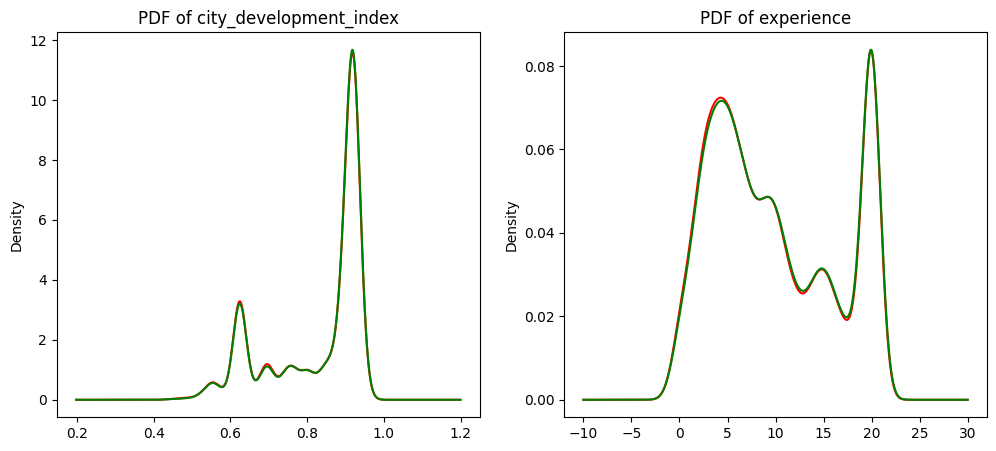

In [39]:
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)

# before dropping the null values(original data)
df["city_development_index"].plot.density(color="red")

# after dropping the null values
new_df["city_development_index"].plot.density(color="green")
plt.title("PDF of city_development_index")

ax2 = fig.add_subplot(122)
# before dropping the null values(original data)
df["experience"].plot.density(color="red")

# after dropping the null values
new_df["experience"].plot.density(color="green")
plt.title("PDF of experience")

plt.show()

In [40]:
# percentage of observations per category, original data

In [44]:
df["enrolled_university"].value_counts()/len(df)*100

enrolled_university
no_enrollment       72.121307
Full time course    19.610607
Part time course     6.253262
Name: count, dtype: float64

In [45]:
# percentage of observations per category, data after cca

In [46]:
new_df["enrolled_university"].value_counts()/len(new_df)*100

enrolled_university
no_enrollment       73.518799
Full time course    20.073333
Part time course     6.407869
Name: count, dtype: float64

In [53]:
temp = pd.concat([df["enrolled_university"].value_counts()/len(df)*100, new_df["enrolled_university"].value_counts()/len(new_df)*100], axis=1)

In [54]:
temp.columns = ["original", "cca"]

In [55]:
temp

,original,cca
enrolled_university,,
no_enrollment,72.121307,73.518799
Full time course,19.610607,20.073333
Part time course,6.253262,6.407869


In [56]:
temp1 = pd.concat([df["education_level"].value_counts()/len(df)*100, new_df["education_level"].value_counts()/len(new_df)*100], axis=1)

In [57]:
temp1.columns = ["original", "cca"]

In [58]:
temp1

,original,cca
education_level,,
Graduate,60.538678,61.983471
Masters,22.763336,23.408218
High School,10.528239,10.737982
Phd,2.160977,2.211617
Primary School,1.607683,1.658713
